Matplotlib is building the font cache; this may take a moment.


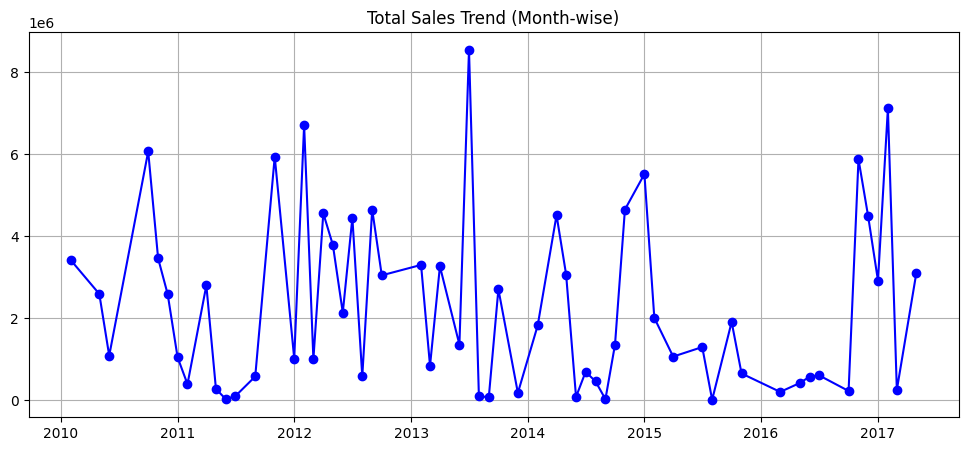

C:\Users\sahad\AppData\Local\Temp\ipykernel_8768\1687368684.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Amount', y='Category', data=df, estimator=sum, ci=None, palette='viridis')
C:\Users\sahad\AppData\Local\Temp\ipykernel_8768\1687368684.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Amount', y='Category', data=df, estimator=sum, ci=None, palette='viridis')


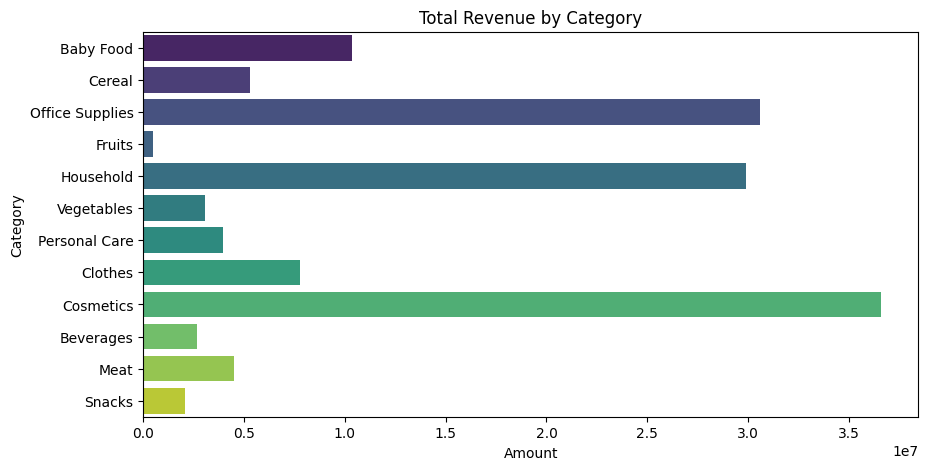

Running K-Means Clustering...
✅ Clustering Complete! Here is how your AI grouped the data:
Performance_Label
Low Performance       68
Medium Performance    23
High Performance       9
Name: count, dtype: int64
💾 AI-Enhanced Data Saved.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

#Loading the Data
df = pd.read_csv('../data/processed/featured_amazon_sales.csv')
df['Date'] = pd.to_datetime(df['Date'])

#VISUALIZATION 1: Sales Trend Over Time
plt.figure(figsize=(12, 5))
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='b')
plt.title('Total Sales Trend (Month-wise)')
plt.grid(True)
plt.show()

#VISUALIZATION 2: Best Selling Categories
plt.figure(figsize=(10, 5))
sns.barplot(x='Amount', y='Category', data=df, estimator=sum, ci=None, palette='viridis')
plt.title('Total Revenue by Category')
plt.show()

#Market Segmentation(Clustering)
print("Running K-Means Clustering...")

#Prepare data--numbers
X = df[['Amount']] 

#Train
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

cluster_centers = df.groupby('Cluster')['Amount'].mean().sort_values()

label_map = {
    cluster_centers.index[0]: 'Low Performance',
    cluster_centers.index[1]: 'Medium Performance',
    cluster_centers.index[2]: 'High Performance'
}
df['Performance_Label'] = df['Cluster'].map(label_map)

print("✅ Clustering Complete! Here is how your AI grouped the data:")
print(df['Performance_Label'].value_counts())

# Save
df.to_csv('../data/processed/clustered_amazon_sales.csv', index=False)
print("💾 AI-Enhanced Data Saved.")